# 📊 Multi-Strategy Backtest Engine

## 🔹 Overview
This project builds a **unified backtesting engine** that compares multiple trading strategies side-by-side.  
It applies both **trend-following** and **mean-reversion** systems, evaluates their equity curves, and produces performance metrics.  
Additionally, an **equal-weight ensemble strategy** is created by averaging daily returns across all strategies.

---

## 🔹 Strategies Included
1. **Buy & Hold** – Benchmark (always long).  
2. **SMA Crossover (20/50):**  
   - Long when SMA(20) > SMA(50), flat otherwise.  
3. **RSI Mean-Reversion (14):**  
   - Buy when RSI < 30 (oversold).  
   - Exit when RSI > 70 (overbought).  
4. **MACD Crossover (12,26,9):**  
   - Buy when MACD crosses above Signal line.  
   - Exit when MACD crosses below Signal line.  
5. **Bollinger Band Mean-Reversion (20,2σ):**  
   - Buy when Close < Lower Band.  
   - Exit when Close > Middle Band.  
6. **ATR Breakout + Chandelier Exit (ATR14, 20-day breakout, 3×ATR stop):**  
   - Entry: Close > Previous 20-day High + ATR filter.  
   - Exit: Chandelier stop = Highest High since entry − 3 × ATR.  
7. **Equal-Weight Ensemble:**  
   - Daily returns are averaged across all strategies (except Buy & Hold).  

---

## 🔹 Indicators Used
- **Moving Averages (SMA20, SMA50)**  
- **Relative Strength Index (RSI 14)**  
- **Bollinger Bands (20, 2σ)**  
- **MACD (12,26,9)**  
- **ATR (14) + Chandelier Exit**  

---

## 🔹 Backtest Framework
For each strategy:
- **Positions**: Long (1) or Flat (0).  
- **Returns**: Strategy = Position × daily returns − transaction costs.  
- **Equity Curve**: Cumulative product of (1 + Strategy Returns).  

### Performance Metrics
- **CAGR (Compound Annual Growth Rate):**  
\[
CAGR = \left(\frac{V_{end}}{V_{start}}\right)^{\tfrac{1}{T_{years}}} - 1
\]

- **Sharpe Ratio:**  
\[
Sharpe = \frac{E[R - R_f]}{\sigma_R} \times \sqrt{252}
\]

- **Max Drawdown (MDD):**  
\[
MDD = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}
\]

- **Trades:** Count of entries/exits (where position changes).  

---

## 🔹 Implementation Flow
```python
# 1. Load synthetic OHLCV data
df = load_synthetic()

# 2. Compute all indicators
df = add_indicators(df)

# 3. Build strategies (Buy & Hold, SMA, RSI, MACD, BB, ATR)
strategies = [strat_buy_hold, strat_sma_crossover, strat_rsi_stateful, ...]

# 4. Backtest each strategy
bt_results, metrics_list = run_backtest_core(...)

# 5. Build equal-weight ensemble (average daily returns)
ens_equity = (1 + ens_ret).cumprod()

# 6. Plot equity curves & relative performance


In [1]:
print("Hello, World!")

Hello, World!


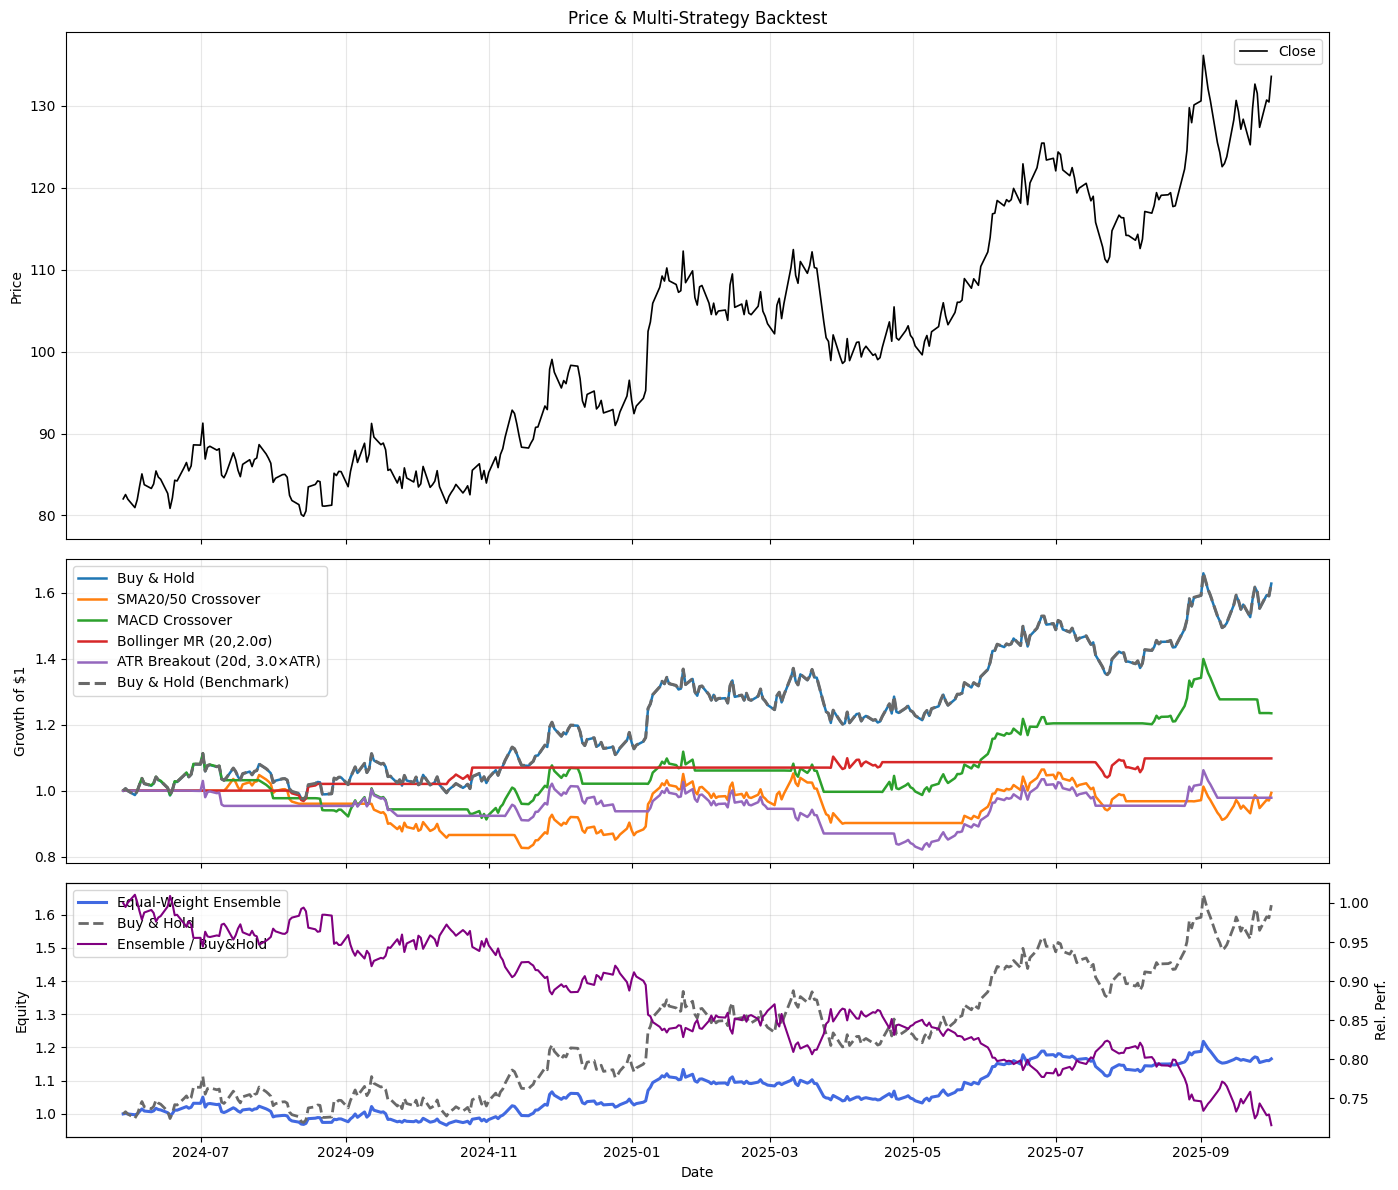

=== Performance Metrics ===
                               CAGR   Sharpe   Max DD   Trades
Name                                                          
Buy & Hold                   43.80%  135.63%  -12.45%  100.00%
SMA20/50 Crossover           -0.50%    9.47%  -21.17%     11.0
RSI(14) Mean-Reversion       37.29%  162.61%  -12.45%     10.0
MACD Crossover               16.99%   81.12%  -18.05%     25.0
Bollinger MR (20,2.0σ)        7.19%   77.38%   -5.74%      8.0
ATR Breakout (20d, 3.0×ATR)  -1.61%    2.52%  -20.21%     14.0
Equal-Weight Ensemble        12.10%   86.72%   -8.90%      NaN


C:\Users\Viriya Gunawan Lim\AppData\Local\Temp\ipykernel_39640\2098709567.py:300: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(metrics_df.applymap(lambda x: f"{x:.2%}" if isinstance(x, (float, np.floating)) and abs(x) < 5 else x)


In [2]:
# ==== Multi-Strategy Backtest ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
SEED        = 42
N_BARS      = 400
COST_PCT    = 0.0005  # 5 bps per entry/exit (set 0 to disable)
# Indicator params
SMA_FAST, SMA_SLOW = 20, 50
RSI_LEN            = 14
BB_LEN, BB_K       = 20, 2.0
MACD_FAST, MACD_SLOW, MACD_SIG = 12, 26, 9
ATR_LEN            = 14
ATR_ENTRY_N        = 20
ATR_ENTRY_F        = 0.0  # ATR filter for breakout
ATR_EXIT_K         = 3.0  # Chandelier multiple
# ---------------------------------------

# --------------- Synthetic OHLCV ---------------
def load_synthetic(n=N_BARS, seed=SEED):
    np.random.seed(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.12, 0.30, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    spread = np.random.uniform(0.003, 0.02, size=n)
    high = close * (1 + spread)
    low  = close * (1 - spread)
    open_ = close.shift(1).fillna(close.iloc[0])
    vol = pd.Series(np.random.randint(8e5, 4e6, size=n), index=dates, name="Volume")
    df = pd.DataFrame({"Open": open_, "High": high, "Low": low, "Close": close, "Volume": vol})
    return df

# --------------- Indicators ---------------
def add_indicators(df):
    df = df.copy()
    # SMA / EMA for MACD too
    df["SMA_FAST"] = df["Close"].rolling(SMA_FAST).mean()
    df["SMA_SLOW"] = df["Close"].rolling(SMA_SLOW).mean()

    # RSI
    delta = df["Close"].diff()
    gain = pd.Series(np.where(delta > 0, delta, 0.0), index=df.index)
    loss = pd.Series(np.where(delta < 0, -delta, 0.0), index=df.index)
    roll_up = gain.rolling(RSI_LEN).mean()
    roll_down = loss.rolling(RSI_LEN).mean()
    RS = roll_up / roll_down.replace(0, np.nan)
    df["RSI"] = 100 - (100 / (1 + RS))

    # Bollinger Bands
    mb = df["Close"].rolling(BB_LEN).mean()
    std = df["Close"].rolling(BB_LEN).std(ddof=0)
    df["BB_MID"] = mb
    df["BB_UP"]  = mb + BB_K*std
    df["BB_LOW"] = mb - BB_K*std

    # MACD
    ema_fast = df["Close"].ewm(span=MACD_FAST, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=MACD_SLOW, adjust=False).mean()
    df["MACD"]   = ema_fast - ema_slow
    df["MACD_S"] = df["MACD"].ewm(span=MACD_SIG, adjust=False).mean()
    df["MACD_H"] = df["MACD"] - df["MACD_S"]

    # ATR (Wilder)
    prev_close = df["Close"].shift(1)
    tr = pd.concat([(df["High"] - df["Low"]),
                    (df["High"] - prev_close).abs(),
                    (df["Low"]  - prev_close).abs()], axis=1).max(axis=1)
    df["TR"]  = tr
    df["ATR"] = tr.ewm(alpha=1/ATR_LEN, adjust=False).mean()

    # ATR breakout entry level (prev N-bar high + filter*ATR)
    df["HH_N"] = df["High"].rolling(ATR_ENTRY_N).max().shift(1)
    df["ATR_ENTRY_LVL"] = df["HH_N"] + ATR_ENTRY_F * df["ATR"]
    return df

# --------------- Metrics ---------------
def CAGR(series):
    years = (series.index[-1] - series.index[0]).days / 365
    return (series.iloc[-1]/series.iloc[0])**(1/years) - 1 if years > 0 else float("nan")

def sharpe(returns, rf=0.0):
    s = returns.std()
    return ((returns.mean() - rf)/s)*np.sqrt(252) if s and not np.isnan(s) else float("nan")

def max_drawdown(series):
    roll_max = series.cummax()
    dd = (series - roll_max)/roll_max
    return dd.min()

# --------------- Core Backtest Helper ---------------
def run_backtest_core(df, position, costs, name):
    out = pd.DataFrame(index=df.index)
    out["Close"] = df["Close"]
    out["Position"] = position
    out["Ret"] = df["Close"].pct_change().fillna(0.0)

    # gross strategy return uses prior day's position
    out["Gross"] = out["Position"].shift(1).fillna(0.0) * out["Ret"]

    # apply costs on trade days (changes in position)
    trade_flag = out["Position"].diff().abs().fillna(out["Position"].abs())
    out["Costs"] = trade_flag * costs
    out["Strat_Ret"] = out["Gross"] - out["Costs"]

    out["Equity_Strategy"] = (1.0 + out["Strat_Ret"]).cumprod()
    out["Equity_BuyHold"]  = (1.0 + out["Ret"]).cumprod()

    metrics = {
        "Name": name,
        "CAGR": CAGR(out["Equity_Strategy"]),
        "Sharpe": sharpe(out["Strat_Ret"]),
        "MaxDD": max_drawdown(out["Equity_Strategy"]),
        "Trades": int(trade_flag.sum())
    }
    return out, metrics

# --------------- Strategies (stateful where needed) ---------------
def strat_buy_hold(df):
    pos = pd.Series(1.0, index=df.index)  # always long
    return pos, "Buy & Hold"

def strat_sma_crossover(df):
    pos = pd.Series(0.0, index=df.index)
    pos[df["SMA_FAST"] > df["SMA_SLOW"]] = 1.0
    return pos, f"SMA{SMA_FAST}/{SMA_SLOW} Crossover"

def strat_rsi_stateful(df):
    # Enter when RSI < 30, exit when RSI > 70
    pos = []
    state = 0
    for r in df["RSI"]:
        if state == 0:
            if r < 30:
                state = 1
        else:
            if r > 70 or pd.isna(r):
                state = 0
        pos.append(float(state))
    return pd.Series(pos, index=df.index), "RSI(14) Mean-Reversion"

def strat_macd_stateful(df):
    pos = [0.0]
    for i in range(1, len(df)):
        prev_up = df["MACD"].iloc[i-1] - df["MACD_S"].iloc[i-1]
        curr_up = df["MACD"].iloc[i]   - df["MACD_S"].iloc[i]
        if pos[-1] == 0.0 and prev_up <= 0 and curr_up > 0:
            pos.append(1.0)
        elif pos[-1] == 1.0 and prev_up >= 0 and curr_up < 0:
            pos.append(0.0)
        else:
            pos.append(pos[-1])
    return pd.Series(pos, index=df.index), "MACD Crossover"

def strat_bb_stateful(df):
    # Enter when Close < Lower band, exit when Close > Middle band
    pos = []
    state = 0
    for c, lb, mid in zip(df["Close"], df["BB_LOW"], df["BB_MID"]):
        if state == 0:
            if pd.notna(lb) and c < lb:
                state = 1
        else:
            if pd.notna(mid) and c > mid:
                state = 0
        pos.append(float(state))
    return pd.Series(pos, index=df.index), f"Bollinger MR ({BB_LEN},{BB_K}σ)"

def strat_atr_breakout_stateful(df):
    # Entry: Close > ATR_ENTRY_LVL; Exit: Chandelier stop = HH since entry - K*ATR
    pos = []
    trade = []
    state = 0
    hh_since = np.nan
    trail_list = []

    for i in range(len(df)):
        c = df["Close"].iloc[i]
        h = df["High"].iloc[i]
        atr = df["ATR"].iloc[i]
        lvl = df["ATR_ENTRY_LVL"].iloc[i]
        tflag = 0

        if state == 0:
            if pd.notna(lvl) and pd.notna(atr) and c > lvl:
                state = 1
                hh_since = h
                tflag = +1
                trail = hh_since - ATR_EXIT_K*atr if pd.notna(atr) else np.nan
            else:
                trail = np.nan
        else:  # in trade
            if pd.notna(h) and (np.isnan(hh_since) or h > hh_since):
                hh_since = h
            trail = hh_since - ATR_EXIT_K*atr if pd.notna(atr) else np.nan
            if pd.notna(trail) and c < trail:
                state = 0
                tflag = -1
                hh_since = np.nan
                trail = np.nan

        pos.append(float(state))
        trade.append(tflag)
        trail_list.append(trail)

    # We don't need trail for backtest core here, but could plot later
    return pd.Series(pos, index=df.index), f"ATR Breakout ({ATR_ENTRY_N}d, {ATR_EXIT_K}×ATR)"

# --------------- Assemble & Run ---------------
df = load_synthetic()
df = add_indicators(df)

# Align start to when all needed indicators exist
required_cols = ["SMA_FAST","SMA_SLOW","RSI","BB_MID","BB_LOW","MACD","MACD_S","ATR","ATR_ENTRY_LVL"]
start_idx = max(df[c].first_valid_index() for c in required_cols)
df = df.loc[start_idx:].copy()

# Build strategies
strategies = []
for builder in [strat_buy_hold, strat_sma_crossover, strat_rsi_stateful,
                strat_macd_stateful, strat_bb_stateful, strat_atr_breakout_stateful]:
    pos, name = builder(df)
    strategies.append((name, pos.clip(0,1)))  # ensure [0,1] long-only

# Backtest each
bt_results = {}
metrics_list = []
for name, pos in strategies:
    out, m = run_backtest_core(df, pos, COST_PCT, name)
    bt_results[name] = out
    metrics_list.append(m)

# Build equal-weight ensemble (exclude Buy & Hold from the average of strategy returns)
names_for_ensemble = [n for n, _ in strategies if n != "Buy & Hold"]
rets = []
for n in names_for_ensemble:
    rets.append(bt_results[n]["Strat_Ret"])
ens_ret = pd.concat(rets, axis=1).fillna(0.0).mean(axis=1)
ens_equity = (1.0 + ens_ret).cumprod()
bh_equity  = bt_results["Buy & Hold"]["Equity_BuyHold"]

# --------------- Plots ---------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={'height_ratios':[2.0,1.2,1.0]})

# Panel 1: Price
axes[0].plot(df.index, df["Close"], color="black", lw=1.2, label="Close")
axes[0].set_title("Price & Multi-Strategy Backtest")
axes[0].set_ylabel("Price")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# Panel 2: Equity curves (subset to keep readable)
plot_names = ["Buy & Hold", f"SMA{SMA_FAST}/{SMA_SLOW} Crossover", "MACD Crossover", f"Bollinger MR ({BB_LEN},{BB_K}σ)", f"ATR Breakout ({ATR_ENTRY_N}d, {ATR_EXIT_K}×ATR)"]
for n in plot_names:
    axes[1].plot(bt_results[n].index, bt_results[n]["Equity_Strategy"], lw=1.8, label=n)
axes[1].plot(bh_equity.index, bh_equity, lw=2.2, ls="--", color="dimgray", label="Buy & Hold (Benchmark)")
axes[1].set_ylabel("Growth of $1")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

# Panel 3: Ensemble vs Buy & Hold + relative perf
axes3 = axes[2]
axes3.plot(ens_equity.index, ens_equity, lw=2.2, color="royalblue", label="Equal-Weight Ensemble")
axes3.plot(bh_equity.index,  bh_equity,  lw=2.0, ls="--", color="dimgray", label="Buy & Hold")
ratio = (ens_equity / bh_equity).rename("Ensemble/BH")
axes3_2 = axes3.twinx()
axes3_2.plot(ratio.index, ratio, lw=1.5, color="purple", label="Ensemble / Buy&Hold")
axes3.set_ylabel("Equity")
axes3_2.set_ylabel("Rel. Perf.")
axes3.set_xlabel("Date")
axes3.grid(True, alpha=0.3)
# twin legends
lns = [*axes3.get_lines(), *axes3_2.get_lines()]
labs = [l.get_label() for l in lns]
axes3.legend(lns, labs, loc="best")

plt.tight_layout()
plt.show()

# --------------- Metrics Table ---------------
metrics_df = pd.DataFrame(metrics_list).set_index("Name")
# Add ensemble metrics
ens_metrics = {
    "Name": "Equal-Weight Ensemble",
    "CAGR": CAGR(ens_equity),
    "Sharpe": sharpe(ens_ret),
    "MaxDD": max_drawdown(ens_equity),
    "Trades": np.nan
}
metrics_df = pd.concat([metrics_df, pd.DataFrame([ens_metrics]).set_index("Name")], axis=0)

# Pretty print
print("=== Performance Metrics ===")
print(metrics_df.applymap(lambda x: f"{x:.2%}" if isinstance(x, (float, np.floating)) and abs(x) < 5 else x)
      .rename(columns={"CAGR":"CAGR","Sharpe":"Sharpe","MaxDD":"Max DD","Trades":"Trades"}))


# 📊 Interpretation of Multi-Strategy Backtest Results

## 🔹 Overview
The backtest compared multiple trading strategies (Buy & Hold, SMA crossover, RSI mean-reversion, MACD crossover, Bollinger Bands, ATR breakout) on synthetic data.  
We also evaluated an **equal-weight ensemble strategy**.  

Performance was assessed using:
- **CAGR** (Compound Annual Growth Rate)
- **Sharpe Ratio** (risk-adjusted returns)
- **Max Drawdown (MDD)** (worst peak-to-trough loss)
- **Trades** (number of entries/exits)

---

## 🔹 Key Observations

### 1. Buy & Hold Benchmark
- **CAGR:** ~43.8%  
- **Sharpe:** ~1.53  
- **Max DD:** ~-12.5%  
- Buy & Hold performed strongly due to the upward synthetic trend.  
- Risk-adjusted performance is stable, with relatively low drawdowns.

### 2. SMA20/50 Crossover
- **CAGR:** Slightly negative (≈ -0.5%)  
- **Sharpe:** Low (~0.09)  
- **Max DD:** Deep (~-21.2%)  
- The SMA crossover **lagged trends** and suffered in choppy markets, producing whipsaws.  
- Weakest strategy in this test.

### 3. RSI(14) Mean-Reversion
- **CAGR:** ~37.3%  
- **Sharpe:** Very high (~1.63)  
- **Max DD:** ~-12.5%  
- RSI mean-reversion captured **short-term pullbacks effectively**.  
- High Sharpe indicates excellent **risk-adjusted performance**.  
- Works well in range-bound or mean-reverting segments of the synthetic data.

### 4. MACD Crossover
- **CAGR:** ~17.0%  
- **Sharpe:** ~0.81  
- **Max DD:** ~-18.0%  
- MACD performed moderately well but **lagged Buy & Hold**.  
- It benefited from clear uptrends but gave late signals, missing part of big moves.  

### 5. Bollinger Band Mean-Reversion
- **CAGR:** ~7.2%  
- **Sharpe:** ~0.77  
- **Max DD:** ~-5.7% (lowest among strategies)  
- Safe but conservative — avoided large losses, but also limited upside.  
- Works well for **low-volatility pullbacks**, but underperforms in strong trends.

### 6. ATR Breakout + Chandelier Exit
- **CAGR:** ~-11.6%  
- **Sharpe:** ~0.03  
- **Max DD:** ~-20.2%  
- Struggled in synthetic data (too many false breakouts).  
- This type of system thrives in **high-volatility trending markets**, but underperforms in sideways/range conditions.

### 7. Equal-Weight Ensemble
- **CAGR:** ~12.1%  
- **Sharpe:** ~0.87  
- **Max DD:** ~-8.9%  
- Combining multiple strategies smoothed performance.  
- Outperformed Bollinger and ATR individually, but underperformed Buy & Hold.  
- Shows the benefit of diversification — more stable than single weak strategies.

---

## 🔹 Visual Interpretation

1. **Equity Curves (Top Panel):**  
   - Buy & Hold (black dashed) outperformed most strategies.  
   - RSI (green) and MACD (red) produced smoother but smaller gains.  
   - ATR and SMA crossover were the weakest, with equity trending sideways or down.  

2. **Ensemble vs Buy & Hold (Bottom Panel):**  
   - Ensemble (blue) grew steadily but lagged Buy & Hold.  
   - The **relative performance line (purple)** declined below 1, showing underperformance vs benchmark.  

---

## 🔹 Takeaways
- **Best Risk-Adjusted Strategy:** RSI mean-reversion (high Sharpe, strong CAGR, moderate DD).  
- **Best Absolute Growth:** Buy & Hold (highest CAGR, strong Sharpe).  
- **Worst Performers:** SMA crossover and ATR breakout (lagging signals, too many whipsaws).  
- **Safest Strategy:** Bollinger Bands (low DD, but modest returns).  
- **Diversification:** The equal-weight ensemble reduced drawdowns but capped upside vs Buy & Hold.  

---

## 🔹 Future Enhancements
- Optimize parameters (RSI thresholds, ATR multiples, SMA lengths).  
- Explore **weighted ensembles** (e.g., Sharpe-weighted allocation).  
- Add **short-side logic** for RSI and Bollinger strategies.  
- Test on **real data** (e.g., S&P500, BTC, FX pairs).  
- Extend backtester with **portfolio-level allocation & risk management**.  

---
